# Interpretation of modes recovered from CHAOS-8.6

Fit the selected DMD configuration to CHAOS-8.6 radial secular variation at the CMB, then inspect the recovered spatial phasors, cumulative reconstruction error, equatorial evolution, and geographical power.

## Preamble

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = next(
    path for path in (cwd, *cwd.parents)
    if (path / 'src' / 'msc_thesis').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_th

## DMD configuration and recovered-mode set

The defaults reproduce the selected CHAOS setup: maximum spherical-harmonic degree 9, 99.9% SVD-variance truncation, and Hankel embedding dimension 4. All processed modes with period greater than 3 years are retained, including non-oscillatory modes.

In [3]:
chosen_nmax = 9
chosen_svd_rank = 12
chosen_embedding_d = 7
minimum_period = 3.0
wave_period_boundary = 20.0
slice_latitude = 0.0
slice_longitude = 100
misfit_latitude_band = (-20.0, 20.0)
misfit_longitude_band = (80.0, 120.0)
misfit_log_y_scale = False
font_size = 11

chosen_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': True,
    'embedding_d': chosen_embedding_d,
    'weight_flag': True,
}

plt.rcParams.update({
    'font.size': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
})

In [4]:
gnm_chaos = CHAOS_Full_SV_Record_Obtain(
    model_version='CHAOS-8.6.mat',
    nmax=chosen_nmax,
)
A_chaos_r = Truncate_Gauss_Coeffs(A_15_r, tmax=chosen_nmax)
gnm_chaos = Truncate_Gauss_Coeffs(gnm_chaos, tmax=chosen_nmax)
chaos_sv_grid = A_chaos_r @ gnm_chaos.T

chaos_dmd_modes = Run_DMD(
    chaos_sv_grid,
    times_used_relative,
    svd_rank=chosen_svd_rank,
    dmd_settings=chosen_dmd_settings.copy(),
)

recovered_periods = np.asarray(chaos_dmd_modes['periods'], dtype=float)
recovered_eigenvalues = np.asarray(
    chaos_dmd_modes['continuous_eigenvalues'],
    dtype=complex,
)
recovered_phasors = np.asarray(chaos_dmd_modes['phasors'], dtype=complex)
static_mask = np.isclose(recovered_eigenvalues.imag, 0.0)
selected_mask = static_mask | (
    np.isfinite(recovered_periods)
    & (recovered_periods > minimum_period)
)
selected_indices = np.flatnonzero(selected_mask)

feasible_indices = selected_indices[
    (~static_mask[selected_indices])
    & (recovered_periods[selected_indices] <= wave_period_boundary)
]
feasible_indices = feasible_indices[
    np.argsort(recovered_periods[feasible_indices])[::-1]
]
long_period_indices = selected_indices[
    (~static_mask[selected_indices])
    & (recovered_periods[selected_indices] > wave_period_boundary)
]
long_period_indices = long_period_indices[
    np.argsort(recovered_periods[long_period_indices])[::-1]
]
static_indices = selected_indices[static_mask[selected_indices]]
long_or_static_indices = np.concatenate([
    long_period_indices,
    static_indices,
]).astype(int)

chaos_mode_suite = {}
for mode_number, mode_index in enumerate(feasible_indices, start=1):
    chaos_mode_suite[f'mode_{mode_number}'] = {
        'label': f'Mode {mode_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': recovered_periods[mode_index],
        'mode_index': int(mode_index),
        'category': 'feasible',
    }

for long_number, mode_index in enumerate(long_period_indices, start=1):
    chaos_mode_suite[f'long_period_{long_number}'] = {
        'label': f'Long Period Wave {long_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': recovered_periods[mode_index],
        'mode_index': int(mode_index),
        'category': 'long_period',
    }

for static_number, mode_index in enumerate(static_indices, start=1):
    chaos_mode_suite[f'static_{static_number}'] = {
        'label': f'Static Field {static_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': np.inf,
        'mode_index': int(mode_index),
        'category': 'static',
    }

feasible_mode_keys = [
    key for key, info in chaos_mode_suite.items()
    if info['category'] == 'feasible'
]
long_or_static_mode_keys = [
    key for key, info in chaos_mode_suite.items()
    if info['category'] in {'long_period', 'static'}
]

print(f"Effective DMD rank: {chaos_dmd_modes['effective_rank']}")
print(f'Retained modes with period > {minimum_period:g} years: '
      f'{len(chaos_mode_suite)}')
for mode_info in chaos_mode_suite.values():
    eigenvalue = mode_info['eigenvalue']
    if mode_info['category'] == 'static':
        period_text = 'no imaginary component'
    else:
        period_text = f"{mode_info['period']:.2f} years"
    print(
        f"  {mode_info['label']}: {period_text}; "
        f"lambda = {eigenvalue.real:.4f} "
        f"{eigenvalue.imag:+.4f}i yr^-1"
    )

Effective DMD rank: 12
Retained modes with period > 3 years: 6
  Mode 1: 13.28 years; lambda = 0.0041 +0.4731i yr^-1
  Mode 2: 7.62 years; lambda = -0.0321 +0.8245i yr^-1
  Mode 3: 5.75 years; lambda = -0.0348 +1.0928i yr^-1
  Mode 4: 4.26 years; lambda = -0.0388 +1.4751i yr^-1
  Long Period Wave 1: 96.01 years; lambda = -0.0264 +0.0654i yr^-1
  Long Period Wave 2: 23.41 years; lambda = -0.1391 +0.2685i yr^-1


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 113376.4120852725. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


## Reconstruction and plotting helpers

`Run_DMD` returns amplitude-scaled processed phasors. Their physical radial-SV contribution is therefore reconstructed at time $t$ after 2000 as $\operatorname{Re}[\phi_j\exp(\lambda_j t)]$.

In [5]:
def Evaluate_Recovered_Mode(mode_info, times=times_used_relative):
    phasor = np.asarray(mode_info['phasor'], dtype=complex).ravel()
    eigenvalue = complex(mode_info['eigenvalue'])
    dynamics = np.exp(eigenvalue * np.asarray(times, dtype=float))
    return np.real(dynamics[:, None] * phasor[None, :])


def Format_Eigenvalue(eigenvalue):
    eigenvalue = complex(eigenvalue)
    sign = '+' if eigenvalue.imag >= 0 else '-'
    return (
        rf'$\lambda={eigenvalue.real:.3f}{sign}'
        rf'{abs(eigenvalue.imag):.3f}i$ yr$^{{-1}}$'
    )


def Period_Text(mode_info):
    if mode_info['category'] == 'static':
        return r'$T = \infty$'
    return f"T = {mode_info['period']:.2f} yr"


longitude_plot = ((np.asarray(longitude) + 180) % 360) - 180
longitude_order = np.argsort(longitude_plot)
longitude_plot = longitude_plot[longitude_order]


def Add_Cyclic_Longitude(field):
    field = np.asarray(field)[..., longitude_order]
    return add_cyclic_point(field, coord=longitude_plot, axis=-1)


def Resolve_Grid_Slices(requested_latitude, requested_longitude):
    requested_latitude = float(requested_latitude)
    requested_longitude = float(requested_longitude)
    longitude_modulo = np.mod(requested_longitude, 360.0)

    latitude_indices = np.flatnonzero(
        np.isclose(latitude, requested_latitude)
    )
    longitude_indices = np.flatnonzero(
        np.isclose(np.mod(longitude, 360.0), longitude_modulo)
    )
    if latitude_indices.size != 1:
        raise ValueError(
            f'Slice latitude {requested_latitude:g}° is not a unique '
            'latitude on the DMD grid.'
        )
    if longitude_indices.size != 1:
        raise ValueError(
            f'Slice longitude {requested_longitude:g}° is not a unique '
            'longitude on the DMD grid.'
        )

    plotted_longitude = ((longitude_modulo + 180.0) % 360.0) - 180.0
    return (
        requested_latitude,
        plotted_longitude,
        int(latitude_indices[0]),
        int(longitude_indices[0]),
    )


def Format_Latitude(latitude_value):
    if np.isclose(latitude_value, 0.0):
        return '0° latitude'
    hemisphere = 'N' if latitude_value > 0 else 'S'
    return f'{abs(latitude_value):g}°{hemisphere}'


def Format_Longitude(longitude_value):
    if np.isclose(longitude_value, 0.0):
        return '0° longitude'
    if np.isclose(abs(longitude_value), 180.0):
        return '180° longitude'
    hemisphere = 'E' if longitude_value > 0 else 'W'
    return f'{abs(longitude_value):g}°{hemisphere}'


def Format_Compact_Colourbar_Value(value):
    value = float(value)
    if np.isclose(value, 0.0):
        return '0'
    exponent = int(np.floor(np.log10(abs(value))))
    if abs(exponent) >= 3:
        mantissa = value / (10.0 ** exponent)
        return rf'${mantissa:.2g}\times10^{{{exponent}}}$'
    return f'{value:.3g}'


def Discrete_Seismic_Colormap_And_Norm(colour_limit, step=100.0):
    colour_limit = float(colour_limit)
    step = float(step)
    if not np.isfinite(colour_limit) or colour_limit <= 0:
        raise ValueError('colour_limit must be positive and finite.')
    if not np.isfinite(step) or step <= 0:
        raise ValueError('step must be positive and finite.')

    colour_limit = step * np.ceil(colour_limit / step)
    boundaries = np.arange(
        -colour_limit,
        colour_limit + step,
        step,
    )
    interval_centres = 0.5 * (boundaries[:-1] + boundaries[1:])
    base = plt.get_cmap('seismic')
    colours = base(
        (interval_centres + colour_limit) / (2.0 * colour_limit)
    )
    colours[np.abs(interval_centres) < step] = (1.0, 1.0, 1.0, 1.0)
    cmap = ListedColormap(colours, name='discrete_seismic_sv')
    norm = BoundaryNorm(boundaries, cmap.N, clip=True)
    return cmap, norm, boundaries, colour_limit


def Save_Interpretation_Figure(figure, file_stem, dpi=600):
    output_directory = Path(RESULT_DIR)
    output_directory.mkdir(parents=True, exist_ok=True)
    saved_paths = {}
    for suffix in ('png', 'pdf'):
        output_path = output_directory / f'{file_stem}.{suffix}'
        figure.savefig(output_path, dpi=dpi, facecolor='white')
        saved_paths[suffix] = output_path
    return saved_paths


def Add_Compact_Horizontal_Colourbar(
    fig,
    grid_cell,
    mappable,
    minimum,
    maximum,
    label,
    font_size,
    tick_values=None,
):
    host_axis = fig.add_subplot(grid_cell)
    host_axis.axis('off')
    colourbar_axis = host_axis.inset_axes([0.22, 0.48, 0.56, 0.20])
    colourbar = fig.colorbar(
        mappable,
        cax=colourbar_axis,
        orientation='horizontal',
    )
    if tick_values is None:
        colourbar.set_ticks([])
    else:
        tick_values = np.asarray(tick_values, dtype=float)
        colourbar.set_ticks(tick_values)
        colourbar.set_ticklabels([
            Format_Compact_Colourbar_Value(value)
            for value in tick_values
        ])
        colourbar.ax.tick_params(
            labelsize=font_size - 1,
            length=2,
            pad=2,
        )
    colourbar_axis.set_xlabel(
        label,
        fontsize=font_size,
        labelpad=3,
    )
    if tick_values is None:
        host_axis.text(
            0.19,
            0.58,
            Format_Compact_Colourbar_Value(minimum),
            transform=host_axis.transAxes,
            ha='right',
            va='center',
            fontsize=font_size - 1,
        )
        host_axis.text(
            0.81,
            0.58,
            Format_Compact_Colourbar_Value(maximum),
            transform=host_axis.transAxes,
            ha='left',
            va='center',
            fontsize=font_size - 1,
        )
    return colourbar


def Style_Geographic_Axis(
    axis,
    coastline_colour='0.15',
    coastline_linewidth=0.45,
    gridline_colour='0.15',
    draw_gridline_labels=False,
    slice_latitude=None,
    slice_longitude=None,
    slice_colour='white',
):
    axis.set_global()
    axis.coastlines(
        resolution='110m',
        color=coastline_colour,
        linewidth=coastline_linewidth,
    )
    gridliner = axis.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=draw_gridline_labels,
        xlocs=np.arange(-180, 181, 60),
        ylocs=np.arange(-60, 61, 30),
        color=gridline_colour,
        linewidth=0.45,
        alpha=0.35,
        linestyle=':',
        x_inline=False,
        y_inline=False,
    )
    gridliner.top_labels = False
    gridliner.right_labels = False

    if slice_latitude is not None:
        axis.plot(
            np.linspace(-180, 180, 361),
            np.full(361, slice_latitude),
            transform=ccrs.PlateCarree(),
            color=slice_colour,
            linewidth=1.15,
            linestyle='--',
            zorder=5,
        )
    if slice_longitude is not None:
        axis.plot(
            np.full(181, slice_longitude),
            np.linspace(-90, 90, 181),
            transform=ccrs.PlateCarree(),
            color=slice_colour,
            linewidth=1.15,
            linestyle=(0, (5, 2, 1, 2)),
            zorder=5,
        )

    return gridliner


def Plot_CHAOS_Phasors(
    mode_suite,
    mode_keys,
    figure_width=text_width,
    row_height=1.12,
    font_size=11,
    slice_latitude=None,
    slice_longitude=None,
    show_gridline_labels=False,
):
    if not mode_keys:
        raise ValueError('At least one mode is required for a phasor plot.')
    if (slice_latitude is None) != (slice_longitude is None):
        raise ValueError(
            'slice_latitude and slice_longitude must be supplied together.'
        )
    if slice_latitude is not None:
        (
            slice_latitude,
            slice_longitude,
            _,
            _,
        ) = Resolve_Grid_Slices(slice_latitude, slice_longitude)

    n_modes = len(mode_keys)
    figure_height = row_height * n_modes + 0.35
    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        n_modes + 1,
        4,
        width_ratios=(1.20, 2.65, 2.65, 0.12),
        height_ratios=[0.12] + ([1.0] * n_modes),
    )
    axes = np.empty((n_modes, 2), dtype=object)
    for column, column_label in enumerate(
        ('Real', 'Imaginary'),
        start=1,
    ):
        heading_axis = fig.add_subplot(grid[0, column])
        heading_axis.axis('off')
        heading_axis.text(
            0.5,
            0.0,
            column_label,
            transform=heading_axis.transAxes,
            ha='center',
            va='bottom',
            fontsize=font_size,
        )

    phasor_grids = {}
    for mode_key in mode_keys:
        phasor_grid = np.asarray(
            mode_suite[mode_key]['phasor'],
            dtype=complex,
        ).reshape(state_shape)
        real_grid, cyclic_longitude = Add_Cyclic_Longitude(
            phasor_grid.real
        )
        imaginary_grid, _ = Add_Cyclic_Longitude(phasor_grid.imag)
        row_colour_values = np.concatenate([
            real_grid.ravel(),
            imaginary_grid.ravel(),
        ])
        colour_limit = np.nanmax(np.abs(row_colour_values))
        if not np.isfinite(colour_limit) or colour_limit == 0:
            colour_limit = 1.0
        phasor_grids[mode_key] = (
            real_grid,
            imaginary_grid,
            cyclic_longitude,
            colour_limit,
        )

    for row, mode_key in enumerate(mode_keys):
        mode_info = mode_suite[mode_key]
        (
            real_grid,
            imaginary_grid,
            cyclic_longitude,
            colour_limit,
        ) = phasor_grids[mode_key]
        eigenvalue = complex(mode_info['eigenvalue'])
        sign = '+' if eigenvalue.imag >= 0 else '-'

        information_axis = fig.add_subplot(grid[row + 1, 0])
        information_axis.axis('off')
        information_axis.text(
            0.98,
            0.5,
            (
                f"{mode_info['label']}\n"
                rf"$\lambda={eigenvalue.real:.3f}$" '\n'
                rf"${sign}{abs(eigenvalue.imag):.3f}i$ yr$^{{-1}}$" '\n'
                f"{Period_Text(mode_info)}"
            ),
            transform=information_axis.transAxes,
            ha='right',
            va='center',
            fontsize=font_size,
            linespacing=1.15,
        )

        axes[row, 0] = fig.add_subplot(
            grid[row + 1, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )
        axes[row, 1] = fig.add_subplot(
            grid[row + 1, 2],
            projection=ccrs.Robinson(central_longitude=0),
        )
        real_mesh = axes[row, 0].pcolormesh(
            cyclic_longitude,
            latitude,
            real_grid,
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='PuOr',
            vmin=-colour_limit,
            vmax=colour_limit,
            rasterized=True,
        )

        if mode_info['category'] == 'static':
            axes[row, 1].text(
                0.5,
                0.5,
                'No imaginary\ncomponent',
                transform=axes[row, 1].transAxes,
                ha='center',
                va='center',
                fontsize=font_size,
            )
        else:
            axes[row, 1].pcolormesh(
                cyclic_longitude,
                latitude,
                imaginary_grid,
                transform=ccrs.PlateCarree(),
                shading='auto',
                cmap='PuOr',
                vmin=-colour_limit,
                vmax=colour_limit,
                rasterized=True,
            )

        for column, axis in enumerate(axes[row]):
            gridliner = Style_Geographic_Axis(
                axis,
                draw_gridline_labels=show_gridline_labels,
                slice_latitude=slice_latitude,
                slice_longitude=slice_longitude,
                slice_colour='0.15',
            )
            if show_gridline_labels:
                gridliner.bottom_labels = False
                gridliner.left_labels = (column == 0)

        colourbar_axis = fig.add_subplot(grid[row + 1, 3])
        colourbar = fig.colorbar(
            real_mesh,
            cax=colourbar_axis,
            orientation='vertical',
        )
        colourbar.set_ticks([-colour_limit, 0.0, colour_limit])
        colourbar.set_ticklabels([
            Format_Compact_Colourbar_Value(-colour_limit),
            '0',
            Format_Compact_Colourbar_Value(colour_limit),
        ])
        colourbar.set_label(
            r'Radial SV (nT yr$^{-1}$)',
            fontsize=font_size - 1,
            labelpad=3,
        )
        colourbar.ax.tick_params(
            labelsize=font_size - 1,
            length=2,
            pad=2,
        )

    return fig, axes


def Plot_Equatorial_And_Power(
    record_suite,
    slice_latitude,
    slice_longitude,
    figure_width=text_width,
    font_size=11,
    sv_step=100.0,
):
    if not record_suite:
        raise ValueError('At least one reconstructed record is required.')

    (
        slice_latitude,
        slice_longitude,
        slice_latitude_index,
        slice_longitude_index,
    ) = Resolve_Grid_Slices(slice_latitude, slice_longitude)
    latitude_order = np.argsort(latitude)
    latitude_plot = np.asarray(latitude)[latitude_order]
    latitude_spacing = np.median(np.diff(latitude_plot))

    n_rows = len(record_suite)
    figure_height = max(2.90 * n_rows + 0.25, 3.85)
    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        n_rows,
        5,
        width_ratios=(0.11, 2.45, 1.05, 1.05, 0.13),
        wspace=0.22,
    )
    axes = []
    expected_shape = (len(times_used), np.prod(state_shape))
    prepared_records = {}
    all_sv_values = []

    for label, record in record_suite.items():
        record = np.asarray(record, dtype=float)
        if record.shape != expected_shape:
            raise ValueError(
                f"Record '{label}' has shape {record.shape}; "
                f"expected {expected_shape}."
            )
        record_grid = record.reshape(len(times_used), *state_shape)
        latitude_slice_sv = record_grid[
            :, slice_latitude_index, :
        ][:, longitude_order]
        longitude_slice_sv = record_grid[
            :, latitude_order, slice_longitude_index
        ]
        mean_power = np.mean(record_grid ** 2, axis=0)
        power_grid, cyclic_longitude = Add_Cyclic_Longitude(mean_power)

        all_sv_values.extend([
            latitude_slice_sv.ravel(),
            longitude_slice_sv.ravel(),
        ])

        finite_power_values = power_grid[np.isfinite(power_grid)]
        if finite_power_values.size == 0:
            raise ValueError(
                f"Power field for '{label}' contains no finite values."
            )
        power_limit = np.max(finite_power_values)
        if power_limit <= 0:
            power_limit = 1.0

        prepared_records[label] = (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        )

    finite_sv_values = np.concatenate(all_sv_values)
    finite_sv_values = finite_sv_values[np.isfinite(finite_sv_values)]
    if finite_sv_values.size == 0:
        raise ValueError('The SV slices contain no finite values.')
    raw_sv_limit = np.max(np.abs(finite_sv_values))
    if raw_sv_limit == 0:
        raw_sv_limit = sv_step
    (
        sv_cmap,
        sv_norm,
        sv_boundaries,
        sv_limit,
    ) = Discrete_Seismic_Colormap_And_Norm(
        raw_sv_limit,
        step=sv_step,
    )

    latitude_slice_extent = (
        -180,
        180,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )
    longitude_slice_extent = (
        latitude_plot[0] - latitude_spacing / 2,
        latitude_plot[-1] + latitude_spacing / 2,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )
    for row, label in enumerate(record_suite):
        (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        ) = prepared_records[label]

        power_axis = fig.add_subplot(
            grid[row, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )
        power_mesh = power_axis.pcolormesh(
            cyclic_longitude,
            latitude,
            np.ma.masked_less_equal(power_grid, 0.0),
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='magma',
            vmin=0.0,
            vmax=power_limit,
            rasterized=True,
        )
        Style_Geographic_Axis(
            power_axis,
            coastline_colour='white',
            coastline_linewidth=0.70,
            gridline_colour='white',
            slice_latitude=slice_latitude,
            slice_longitude=slice_longitude,
            slice_colour='white',
        )
        power_axis.set_title(
            label.replace('\n', '  |  '),
            pad=3,
            fontweight='semibold',
        )

        power_colourbar_axis = fig.add_subplot(grid[row, 0])
        power_colourbar = fig.colorbar(
            power_mesh,
            cax=power_colourbar_axis,
            orientation='vertical',
        )
        power_colourbar.set_ticks([0.0, power_limit])
        power_colourbar.set_ticklabels([
            '0',
            Format_Compact_Colourbar_Value(power_limit),
        ])
        power_colourbar.set_label(
            r'Mean power ((nT yr$^{-1}$)$^2$)',
            fontsize=font_size - 1,
            labelpad=3,
        )
        power_colourbar.ax.yaxis.set_ticks_position('left')
        power_colourbar.ax.yaxis.set_label_position('left')
        power_colourbar.ax.tick_params(
            labelsize=font_size - 1,
            length=2,
            pad=2,
        )

        latitude_slice_axis = fig.add_subplot(
            grid[row, 2],
            sharey=axes[0][1] if axes else None,
        )
        latitude_slice_image = latitude_slice_axis.imshow(
            latitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=latitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )
        latitude_slice_axis.set_ylabel('Year')
        latitude_slice_axis.set_yticks([2000, 2008, 2016, 2024])
        latitude_slice_axis.set_xlim(-180, 180)
        latitude_slice_axis.set_xticks([-180, -90, 0, 90, 180])
        if row == 0:
            latitude_slice_axis.set_title(
                f'Radial SV at {Format_Latitude(slice_latitude)}',
                pad=2,
            )
        latitude_slice_axis.set_xlabel('Longitude (°)')

        longitude_slice_axis = fig.add_subplot(
            grid[row, 3],
            sharey=latitude_slice_axis,
        )
        longitude_slice_image = longitude_slice_axis.imshow(
            longitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=longitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )
        longitude_slice_axis.tick_params(
            axis='y',
            labelleft=False,
        )
        longitude_slice_axis.set_xlim(
            latitude_plot[0],
            latitude_plot[-1],
        )
        longitude_slice_axis.set_xticks([-80, -40, 0, 40, 80])
        if row == 0:
            longitude_slice_axis.set_title(
                f'Radial SV at {Format_Longitude(slice_longitude)}',
                pad=2,
            )
        longitude_slice_axis.set_xlabel('Latitude (°)')

        axes.append((
            power_axis,
            latitude_slice_axis,
            longitude_slice_axis,
        ))

    major_tick_step = max(5.0 * sv_step, sv_step)
    major_tick_limit = major_tick_step * np.floor(
        sv_limit / major_tick_step
    )
    sv_tick_values = np.unique(np.concatenate([
        np.arange(
            -major_tick_limit,
            major_tick_limit + major_tick_step,
            major_tick_step,
        ),
        np.asarray([-sv_limit, -sv_step, 0.0, sv_step, sv_limit]),
    ]))
    sv_tick_values = sv_tick_values[
        (sv_tick_values >= -sv_limit)
        & (sv_tick_values <= sv_limit)
    ]
    sv_colourbar_axis = fig.add_subplot(grid[:, 4])
    sv_colourbar = fig.colorbar(
        latitude_slice_image,
        cax=sv_colourbar_axis,
        orientation='vertical',
        boundaries=sv_boundaries,
        spacing='proportional',
    )
    sv_colourbar.set_ticks(sv_tick_values)
    sv_colourbar.set_ticklabels([
        Format_Compact_Colourbar_Value(value)
        for value in sv_tick_values
    ])
    sv_colourbar.set_label(
        r'Radial SV (nT yr$^{-1}$)',
        fontsize=font_size,
        labelpad=4,
    )
    sv_colourbar.ax.tick_params(
        labelsize=font_size - 1,
        length=2,
        pad=2,
    )

    return fig, np.asarray(axes, dtype=object)

## Recovered spatial phasors

The two figures together retain every recovered processed mode with period greater than 3 years. Mode information is kept outside the maps, and every mode row has its own symmetric `PuOr` radial-SV scale shown by a compact vertical colourbar at the right. The feasible-set figure is enlarged for the main report; coordinate labels are omitted to keep the maps uncluttered. Dashed and dash-dotted lines mark the configured evolution slices.

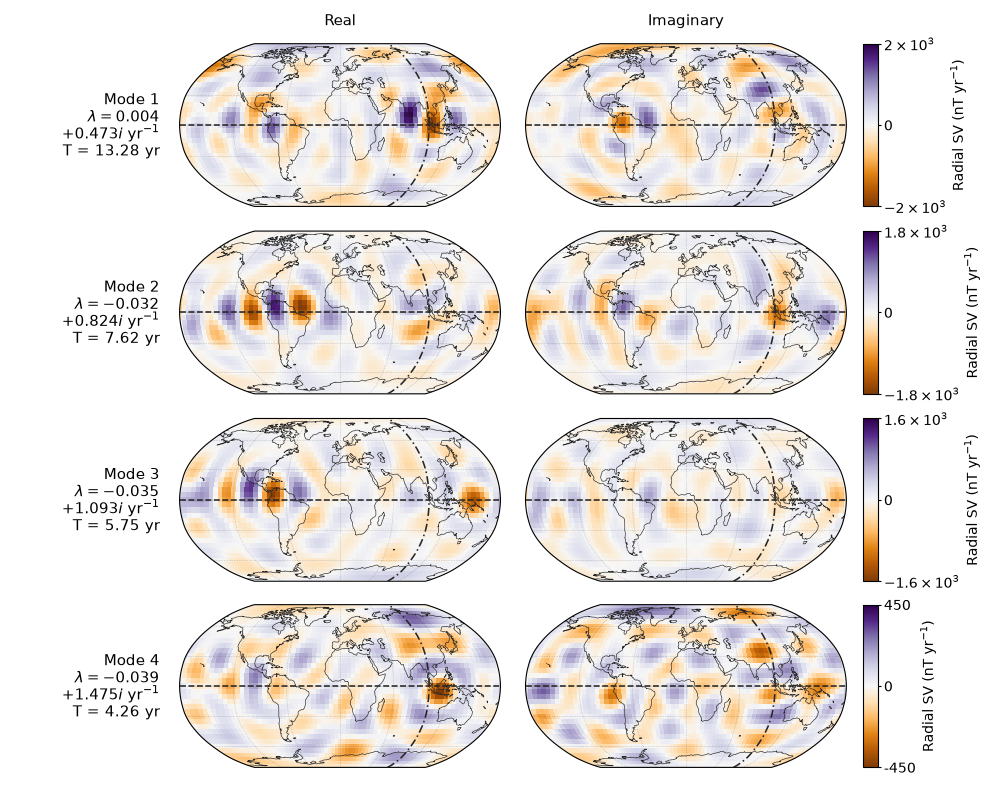

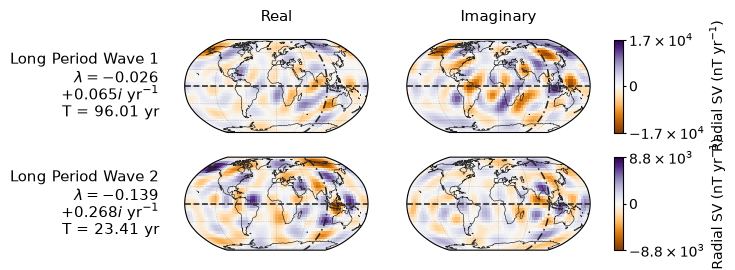

In [6]:
feasible_phasor_figure, feasible_phasor_axes = Plot_CHAOS_Phasors(
    chaos_mode_suite,
    feasible_mode_keys,
    figure_width=1.35 * text_width,
    row_height=1.85,
    font_size=font_size,
    slice_latitude=slice_latitude,
    slice_longitude=slice_longitude,
    show_gridline_labels=False,
)
short_period_phasor_paths = Save_Interpretation_Figure(
    feasible_phasor_figure,
    'chaos_short_period_mode_phasors',
)
plt.show()

long_phasor_figure, long_phasor_axes = Plot_CHAOS_Phasors(
    chaos_mode_suite,
    long_or_static_mode_keys,
    figure_width=text_width,
    font_size=font_size,
    slice_latitude=slice_latitude,
    slice_longitude=slice_longitude,
)
plt.show()

## Cumulative DMD reconstruction misfit

The radial-SV residual is evaluated on the same 5° CMB grid used for DMD. At each time, the plotted metric is the area-weighted root-mean-square residual

$$
E_{\mathrm{RMS}}(t)=\left[\frac{\sum_i w_i\left(B_{r,i}^{\mathrm{CHAOS}}(t)-B_{r,i}^{\mathrm{DMD}}(t)\right)^2}{\sum_i w_i}\right]^{1/2},
\qquad w_i=\cos(\mathrm{latitude}_i).
$$

The first reconstruction contains every long-period or static contribution. Feasible modes are then added from longest to shortest period; Mode 1 is the longest feasible mode. The two regional figures use the same metric and cosine-latitude weights, with the weights renormalized over the selected grid points. Band endpoints are included.

In [7]:
mode_records = {
    mode_key: Evaluate_Recovered_Mode(mode_info)
    for mode_key, mode_info in chaos_mode_suite.items()
}
chaos_record = chaos_sv_grid.T
expected_record_shape = (len(times_used), np.prod(state_shape))
if chaos_record.shape != expected_record_shape:
    raise ValueError(
        f'CHAOS record has shape {chaos_record.shape}; '
        f'expected {expected_record_shape}.'
    )

long_period_sum = np.zeros_like(chaos_record, dtype=float)
for mode_key in long_or_static_mode_keys:
    long_period_sum += mode_records[mode_key]

cumulative_records = {'LP': long_period_sum.copy()}
running_sum = long_period_sum.copy()
included_mode_numbers = []
for mode_number, mode_key in enumerate(feasible_mode_keys, start=1):
    running_sum = running_sum + mode_records[mode_key]
    included_mode_numbers.append(str(mode_number))
    cumulative_label = 'LP+' + '+'.join(included_mode_numbers)
    cumulative_records[cumulative_label] = running_sum.copy()

area_weights = np.asarray(W2D_norm, dtype=float).ravel()
if area_weights.size != chaos_record.shape[1]:
    raise ValueError('Area weights do not match the DMD spatial grid.')
if not np.isclose(np.sum(area_weights), 1.0):
    raise ValueError('Expected normalized area weights to sum to one.')

cumulative_rms_misfit = {}
for label, reconstruction in cumulative_records.items():
    residual = chaos_record - reconstruction
    cumulative_rms_misfit[label] = np.sqrt(
        np.sum(area_weights[None, :] * residual ** 2, axis=1)
    )


def Calculate_Regional_RMS_Misfit(spatial_mask):
    spatial_mask = np.asarray(spatial_mask, dtype=bool).ravel()
    if spatial_mask.size != chaos_record.shape[1]:
        raise ValueError('Regional mask does not match the DMD spatial grid.')
    if not np.any(spatial_mask):
        raise ValueError('Regional mask does not select any grid points.')

    regional_weights = area_weights[spatial_mask]
    regional_weight_sum = np.sum(regional_weights)
    if not np.isfinite(regional_weight_sum) or regional_weight_sum <= 0:
        raise ValueError('Regional area weights must have a positive sum.')

    regional_rms_misfit = {}
    for label, reconstruction in cumulative_records.items():
        regional_residual = (
            chaos_record[:, spatial_mask]
            - reconstruction[:, spatial_mask]
        )
        regional_rms_misfit[label] = np.sqrt(
            np.sum(
                regional_weights[None, :] * regional_residual ** 2,
                axis=1,
            ) / regional_weight_sum
        )
    return regional_rms_misfit


latitude_band_minimum, latitude_band_maximum = map(
    float,
    misfit_latitude_band,
)
if latitude_band_minimum > latitude_band_maximum:
    raise ValueError('Latitude band bounds must be in increasing order.')
latitude_band_mask_2d = np.broadcast_to(
    (
        (np.asarray(latitude) >= latitude_band_minimum)
        & (np.asarray(latitude) <= latitude_band_maximum)
    )[:, None],
    state_shape,
)
latitude_band_rms_misfit = Calculate_Regional_RMS_Misfit(
    latitude_band_mask_2d
)

longitude_band_start, longitude_band_end = np.mod(
    np.asarray(misfit_longitude_band, dtype=float),
    360.0,
)
longitude_modulo = np.mod(np.asarray(longitude, dtype=float), 360.0)
if longitude_band_start <= longitude_band_end:
    longitude_band_mask_1d = (
        (longitude_modulo >= longitude_band_start)
        & (longitude_modulo <= longitude_band_end)
    )
else:
    longitude_band_mask_1d = (
        (longitude_modulo >= longitude_band_start)
        | (longitude_modulo <= longitude_band_end)
    )
longitude_band_mask_2d = np.broadcast_to(
    longitude_band_mask_1d[None, :],
    state_shape,
)
longitude_band_rms_misfit = Calculate_Regional_RMS_Misfit(
    longitude_band_mask_2d
)

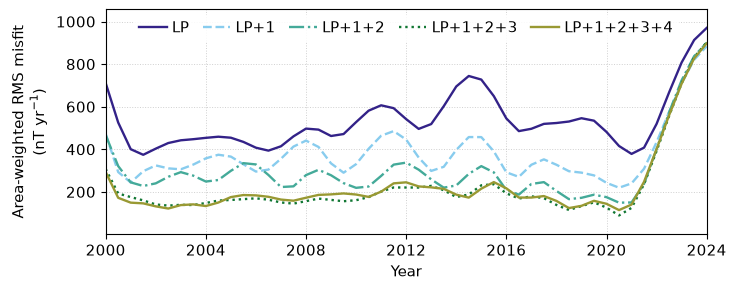

In [8]:
misfit_figure, misfit_axis = plt.subplots(
    figsize=(text_width, 0.70 * 0.55 * text_width),
    constrained_layout=True,
)
line_styles = ['-', '--', '-.', ':']
for line_index, (label, rms_misfit) in enumerate(
    cumulative_rms_misfit.items()
):
    misfit_axis.plot(
        times_used,
        rms_misfit,
        color=tol_muted[line_index % len(tol_muted)],
        linestyle=line_styles[line_index % len(line_styles)],
        linewidth=1.7,
        label=label,
    )
misfit_axis.set(
    xlim=(times_used[0], times_used[-1]),
    xlabel='Year',
    ylabel=r"Area-weighted RMS misfit"+"\n"+r"(nT yr$^{-1}$)",
)
misfit_axis.set_yscale('log' if misfit_log_y_scale else 'linear')
misfit_axis.margins(y=0.10)
misfit_axis.set_xticks(np.arange(2000, 2025, 4))
misfit_axis.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.6)
misfit_axis.legend(
    frameon=True,
    framealpha=0.88,
    edgecolor='none',
    ncol=len(cumulative_rms_misfit),
    loc='upper center',
    bbox_to_anchor=(0.5, 0.99),
    borderaxespad=0.2,
    columnspacing=0.9,
    handlelength=1.8,
    handletextpad=0.35,
)
total_reconstruction_paths = Save_Interpretation_Figure(
    misfit_figure,
    'chaos_total_reconstruction_misfit',
)
plt.show()

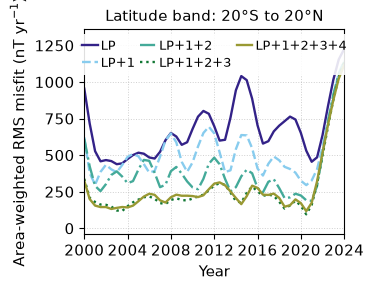

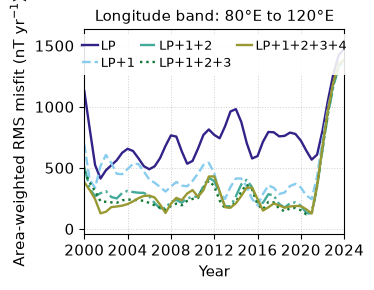

In [9]:
def Plot_Regional_RMS_Misfit(rms_misfit_suite, title):
    figure, axis = plt.subplots(
        figsize=(0.50 * text_width, 0.70 * 0.55 * text_width),
        constrained_layout=True,
    )
    line_styles = ['-', '--', '-.', ':']
    for line_index, (label, rms_misfit) in enumerate(
        rms_misfit_suite.items()
    ):
        axis.plot(
            times_used,
            rms_misfit,
            color=tol_muted[line_index % len(tol_muted)],
            linestyle=line_styles[line_index % len(line_styles)],
            linewidth=1.7,
            label=label,
        )
    axis.set(
        xlim=(times_used[0], times_used[-1]),
        xlabel='Year',
        ylabel=r'Area-weighted RMS misfit (nT yr$^{-1}$)',
        title=title,
    )
    axis.set_yscale('log' if misfit_log_y_scale else 'linear')
    axis.margins(y=0.12)
    axis.set_xticks(np.arange(2000, 2025, 4))
    axis.grid(
        True,
        which='both',
        linestyle=':',
        linewidth=0.7,
        alpha=0.6,
    )
    axis.legend(
        frameon=True,
        framealpha=0.88,
        edgecolor='none',
        ncol=min(3, len(rms_misfit_suite)),
        loc='upper center',
        bbox_to_anchor=(0.5, 0.99),
        borderaxespad=0.2,
        columnspacing=0.45,
        handlelength=1.25,
        handletextpad=0.25,
        labelspacing=0.25,
        fontsize=font_size - 2,
    )
    return figure, axis


latitude_band_misfit_figure, latitude_band_misfit_axis = (
    Plot_Regional_RMS_Misfit(
        latitude_band_rms_misfit,
        title=(
            'Latitude band: '
            f'{Format_Latitude(latitude_band_minimum)} to '
            f'{Format_Latitude(latitude_band_maximum)}'
        ),
    )
)
latitude_band_reconstruction_paths = Save_Interpretation_Figure(
    latitude_band_misfit_figure,
    'chaos_equatorial_band_reconstruction_misfit',
)
plt.show()

longitude_band_start_plot = (
    (longitude_band_start + 180.0) % 360.0
) - 180.0
longitude_band_end_plot = (
    (longitude_band_end + 180.0) % 360.0
) - 180.0
longitude_band_misfit_figure, longitude_band_misfit_axis = (
    Plot_Regional_RMS_Misfit(
        longitude_band_rms_misfit,
        title=(
            'Longitude band: '
            f'{Format_Longitude(longitude_band_start_plot)} to '
            f'{Format_Longitude(longitude_band_end_plot)}'
        ),
    )
)
longitude_band_reconstruction_paths = Save_Interpretation_Figure(
    longitude_band_misfit_figure,
    'chaos_meridional_band_reconstruction_misfit',
)
plt.show()

In [10]:
def Plot_Regional_RMS_Misfit(
    latitude_rms_misfit_suite,
    longitude_rms_misfit_suite,
    latitude_title,
    longitude_title,
):

    figure, axes = plt.subplots(
    1,
    2,
    figsize=(text_width, 0.50 * text_width),
    sharey=True,
)

    # Use 11 pt throughout
    for axis in axes:
        axis.tick_params(axis='both', labelsize=11)
        axis.xaxis.label.set_size(11)
        axis.yaxis.label.set_size(11)
        axis.title.set_size(11)

    line_styles = ['-', '--', '-.', ':']

    # Union of labels, preserving order
    labels = list(dict.fromkeys(
        list(latitude_rms_misfit_suite.keys())
        + list(longitude_rms_misfit_suite.keys())
    ))

    # Give each reconstruction the same style in both panels
    style_map = {
        label: (
            tol_muted[i % len(tol_muted)],
            line_styles[i % len(line_styles)],
        )
        for i, label in enumerate(labels)
    }

    suites = [
        latitude_rms_misfit_suite,
        longitude_rms_misfit_suite,
    ]

    titles = [
        latitude_title,
        longitude_title,
    ]

    for axis, rms_misfit_suite, panel_title in zip(
        axes,
        suites,
        titles,
    ):

        for label, rms_misfit in rms_misfit_suite.items():

            color, linestyle = style_map[label]

            axis.plot(
                times_used,
                rms_misfit,
                color=color,
                linestyle=linestyle,
                linewidth=1.7,
                label=label,
            )

        axis.set(
            xlim=(times_used[0], times_used[-1]),
            xlabel='Year',
            title=panel_title,
        )

        axis.set_yscale(
            'log' if misfit_log_y_scale else 'linear'
        )

        axis.margins(y=0.12)

        axis.set_xticks(
            np.arange(2000, 2025, 4)
        )

        axis.grid(
            True,
            which='both',
            linestyle=':',
            linewidth=0.7,
            alpha=0.6,
        )

    # Shared y-axis label only on left panel
    axes[0].set_ylabel(
        r'Area-weighted RMS misfit (nT yr$^{-1}$)'
    )

    # Build one shared legend
    handles, legend_labels = axes[0].get_legend_handles_labels()

    # Include any labels present only in second panel
    handles_2, labels_2 = axes[1].get_legend_handles_labels()

    for handle, label in zip(handles_2, labels_2):
        if label not in legend_labels:
            handles.append(handle)
            legend_labels.append(label)

    figure.legend(
        handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0),
        ncol=len(legend_labels),
        frameon=True,
        framealpha=0.88,
        edgecolor='none',
        columnspacing=0.8,
        handlelength=1.5,
        handletextpad=0.35,
        labelspacing=0.3,
        fontsize=11,
    )

    # Leave space at bottom for shared legend
    figure.subplots_adjust(
        left=0.11,
        right=0.98,
        top=0.90,
        bottom=0.24,
        wspace=0.18,   # white space between panels
    )
    return figure, axes

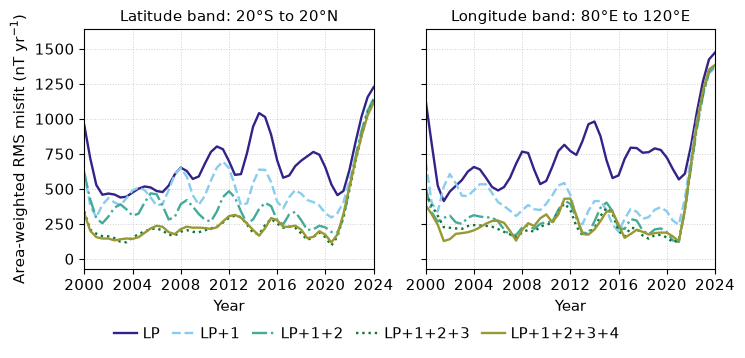

In [11]:
longitude_band_start_plot = (
    (longitude_band_start + 180.0) % 360.0
) - 180.0

longitude_band_end_plot = (
    (longitude_band_end + 180.0) % 360.0
) - 180.0


regional_misfit_figure, regional_misfit_axes = (
    Plot_Regional_RMS_Misfit(
        latitude_band_rms_misfit,
        longitude_band_rms_misfit,

        latitude_title=(
            'Latitude band: '
            f'{Format_Latitude(latitude_band_minimum)} to '
            f'{Format_Latitude(latitude_band_maximum)}'
        ),

        longitude_title=(
            'Longitude band: '
            f'{Format_Longitude(longitude_band_start_plot)} to '
            f'{Format_Longitude(longitude_band_end_plot)}'
        ),
    )
)


regional_reconstruction_paths = Save_Interpretation_Figure(
    regional_misfit_figure,
    'chaos_regional_reconstruction_misfit',
)

plt.show()

## Feasible-wave geographical power and directional evolution

The map in each row shows mean reconstructed radial-SV power, $\langle B_r^2\rangle_t$, over 2000–2024 on a linear scale from zero to that mode's maximum, with its compact vertical colourbar at the row left. The equatorial and meridional SV panels share one symmetric scale across every mode and one tall colourbar at the figure right. The native `seismic` palette is discretized in 100 nT yr$^{-1}$ intervals, with values from −100 to +100 nT yr$^{-1}$ shown in pure white. The meridional panels share the equatorial time axes and omit duplicate year labels.

In [25]:
def Plot_Equatorial_And_Power(
    record_suite,
    slice_latitude,
    slice_longitude,
    figure_width=text_width,
    font_size=11,
    sv_step=100.0,
):
    if not record_suite:
        raise ValueError('At least one reconstructed record is required.')

    (
        slice_latitude,
        slice_longitude,
        slice_latitude_index,
        slice_longitude_index,
    ) = Resolve_Grid_Slices(slice_latitude, slice_longitude)

    latitude_order = np.argsort(latitude)
    latitude_plot = np.asarray(latitude)[latitude_order]
    latitude_spacing = np.median(np.diff(latitude_plot))

    n_rows = len(record_suite)

    figure_height = min(
        1.45 * figure_width,
        1.75 * n_rows + 0.35,
    )

    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )

    grid = fig.add_gridspec(
        n_rows,
        5,
        width_ratios=(0.10, 2.35, 1.05, 1.05, 0.12),
        wspace=0.26,
        hspace=0.18,
    )

    axes = []
    expected_shape = (len(times_used), np.prod(state_shape))
    prepared_records = {}
    all_sv_values = []

    # --------------------------------------------------------------
    # Prepare records
    # --------------------------------------------------------------

    for label, record in record_suite.items():
        record = np.asarray(record, dtype=float)

        if record.shape != expected_shape:
            raise ValueError(
                f"Record '{label}' has shape {record.shape}; "
                f"expected {expected_shape}."
            )

        record_grid = record.reshape(len(times_used), *state_shape)

        latitude_slice_sv = record_grid[
            :, slice_latitude_index, :
        ][:, longitude_order]

        longitude_slice_sv = record_grid[
            :, latitude_order, slice_longitude_index
        ]

        mean_power = np.mean(record_grid ** 2, axis=0)
        power_grid, cyclic_longitude = Add_Cyclic_Longitude(mean_power)

        all_sv_values.extend([
            latitude_slice_sv.ravel(),
            longitude_slice_sv.ravel(),
        ])

        finite_power_values = power_grid[np.isfinite(power_grid)]
        if finite_power_values.size == 0:
            raise ValueError(
                f"Power field for '{label}' contains no finite values."
            )

        power_limit = np.max(finite_power_values)
        if power_limit <= 0:
            power_limit = 1.0

        prepared_records[label] = (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        )

    # --------------------------------------------------------------
    # Shared SV colour scale
    # --------------------------------------------------------------

    finite_sv_values = np.concatenate(all_sv_values)
    finite_sv_values = finite_sv_values[np.isfinite(finite_sv_values)]

    if finite_sv_values.size == 0:
        raise ValueError('The SV slices contain no finite values.')

    raw_sv_limit = np.max(np.abs(finite_sv_values))
    if raw_sv_limit == 0:
        raw_sv_limit = sv_step

    (
        sv_cmap,
        sv_norm,
        sv_boundaries,
        sv_limit,
    ) = Discrete_Seismic_Colormap_And_Norm(
        raw_sv_limit,
        step=sv_step,
    )

    latitude_slice_extent = (
        -180,
        180,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )

    longitude_slice_extent = (
        latitude_plot[0] - latitude_spacing / 2,
        latitude_plot[-1] + latitude_spacing / 2,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )

    # --------------------------------------------------------------
    # Plot rows
    # --------------------------------------------------------------

    for row, label in enumerate(record_suite):
        (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        ) = prepared_records[label]

        # --------------------------
        # Left power colourbar
        # --------------------------

        power_colourbar_axis = fig.add_subplot(grid[row, 0])

        # --------------------------
        # Power map
        # --------------------------

        power_axis = fig.add_subplot(
            grid[row, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )

        power_mesh = power_axis.pcolormesh(
            cyclic_longitude,
            latitude,
            np.ma.masked_less_equal(power_grid, 0.0),
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='magma',
            vmin=0.0,
            vmax=power_limit,
            rasterized=True,
        )

        Style_Geographic_Axis(
            power_axis,
            coastline_colour='white',
            coastline_linewidth=0.70,
            gridline_colour='white',
            slice_latitude=slice_latitude,
            slice_longitude=slice_longitude,
            slice_colour='white',
        )

        power_axis.set_title(
            label.replace('\n', '  |  '),
            fontsize=font_size,
            pad=5,
            fontweight='semibold',
        )

        power_colourbar = fig.colorbar(
            power_mesh,
            cax=power_colourbar_axis,
            orientation='vertical',
        )

        power_colourbar.set_ticks([0.0, power_limit])
        power_colourbar.set_ticklabels([
            '0',
            Format_Compact_Colourbar_Value(power_limit),
        ])

        power_colourbar.ax.yaxis.set_ticks_position('left')
        power_colourbar.ax.yaxis.set_label_position('left')

        power_colourbar.ax.set_ylabel(
            r'Mean power ((nT yr$^{-1}$)$^2$)',
            rotation=90,
            fontsize=font_size,
            labelpad=10,
            va='center',
        )

        # Rotate numerical tick labels so they are parallel
        # to the vertical colourbar.
        power_colourbar.ax.tick_params(
            axis='y',
            labelsize=font_size,
            labelrotation=90,
            length=2,
            pad=5,
        )

        for tick in power_colourbar.ax.get_yticklabels():
            tick.set_rotation(90)
            tick.set_ha('center')
            tick.set_va('center')

        # --------------------------
        # Longitude-time slice
        # --------------------------

        latitude_slice_axis = fig.add_subplot(
            grid[row, 2],
            sharey=axes[0][1] if axes else None,
        )

        latitude_slice_image = latitude_slice_axis.imshow(
            latitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=latitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )

        latitude_slice_axis.set_box_aspect(0.95)

        if row == 0:
            latitude_slice_axis.set_title(
                f'Radial SV at'+'\n'+' {Format_Latitude(slice_latitude)}',
                fontsize=font_size,
                pad=5,
            )

        latitude_slice_axis.set_ylabel(
            'Year',
            fontsize=font_size,
            labelpad=2,
        )

        latitude_slice_axis.set_yticks([
            2000,
            2008,
            2016,
            2024,
        ])

        latitude_slice_axis.set_xlim(-180, 180)

        latitude_slice_axis.set_xticks([
            -180,
            -90,
            0,
            90,
            180,
        ])

        if row == n_rows - 1:
            latitude_slice_axis.set_xlabel(
                'Longitude (°)',
                fontsize=font_size,
                labelpad=4,
            )
        else:
            latitude_slice_axis.tick_params(
                axis='x',
                labelbottom=False,
            )

        latitude_slice_axis.tick_params(
            labelsize=font_size,
            length=3,
            pad=2,
        )

        # --------------------------
        # Latitude-time slice
        # --------------------------

        longitude_slice_axis = fig.add_subplot(
            grid[row, 3],
            sharey=latitude_slice_axis,
        )

        longitude_slice_image = longitude_slice_axis.imshow(
            longitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=longitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )

        longitude_slice_axis.set_box_aspect(0.95)

        if row == 0:
            longitude_slice_axis.set_title(
                f'Radial SV at '+'\n'+'{Format_Longitude(slice_longitude)}',
                fontsize=font_size,
                pad=5,
            )

        longitude_slice_axis.tick_params(
            axis='y',
            labelleft=False,
        )

        longitude_slice_axis.set_xlim(
            latitude_plot[0],
            latitude_plot[-1],
        )

        longitude_slice_axis.set_xticks([
            -80,
            -40,
            0,
            40,
            80,
        ])

        if row == n_rows - 1:
            longitude_slice_axis.set_xlabel(
                'Latitude (°)',
                fontsize=font_size,
                labelpad=4,
            )
        else:
            longitude_slice_axis.tick_params(
                axis='x',
                labelbottom=False,
            )

        longitude_slice_axis.tick_params(
            labelsize=font_size,
            length=3,
            pad=2,
        )

        axes.append((
            power_axis,
            latitude_slice_axis,
            longitude_slice_axis,
        ))

    # --------------------------------------------------------------
    # Shared right-hand SV colourbar
    # --------------------------------------------------------------

    major_tick_step = 5.0 * sv_step
    major_tick_limit = major_tick_step * np.floor(
        sv_limit / major_tick_step
    )

    sv_tick_values = np.unique(np.concatenate([
        np.arange(
            -major_tick_limit,
            major_tick_limit + major_tick_step,
            major_tick_step,
        ),
        np.asarray([-sv_limit, 0.0, sv_limit]),
    ]))

    sv_tick_values = sv_tick_values[
        (sv_tick_values >= -sv_limit)
        & (sv_tick_values <= sv_limit)
    ]

    sv_colourbar_axis = fig.add_subplot(grid[:, 4])

    sv_colourbar = fig.colorbar(
        latitude_slice_image,
        cax=sv_colourbar_axis,
        orientation='vertical',
        boundaries=sv_boundaries,
        spacing='proportional',
    )

    sv_colourbar.set_ticks(sv_tick_values)

    sv_colourbar.set_ticklabels([
        Format_Compact_Colourbar_Value(value)
        for value in sv_tick_values
    ])

    sv_colourbar.ax.yaxis.set_ticks_position('right')
    sv_colourbar.ax.yaxis.set_label_position('right')

    sv_colourbar.ax.set_ylabel(
        r'Radial SV (nT yr$^{-1}$)',
        rotation=270,
        fontsize=font_size,
        labelpad=12,
        va='center',
    )

    # Rotate numerical tick labels so they are parallel
    # to the vertical colourbar.
    sv_colourbar.ax.tick_params(
        axis='y',
        labelsize=font_size,
        labelrotation=90,
        length=2,
        pad=5,
    )

    for tick in sv_colourbar.ax.get_yticklabels():
        tick.set_rotation(90)
        tick.set_ha('center')
        tick.set_va('center')

    # --------------------------------------------------------------
    # Enforce font size everywhere
    # --------------------------------------------------------------

    for axis in fig.axes:
        axis.xaxis.label.set_size(font_size)
        axis.yaxis.label.set_size(font_size)
        axis.title.set_size(font_size)

    return fig, np.asarray(axes, dtype=object)

In [29]:
def Plot_Equatorial_And_Power(
    record_suite,
    slice_latitude,
    slice_longitude,
    figure_width=text_width,
    font_size=11,
    sv_step=100.0,
):
    if not record_suite:
        raise ValueError('At least one reconstructed record is required.')

    (
        slice_latitude,
        slice_longitude,
        slice_latitude_index,
        slice_longitude_index,
    ) = Resolve_Grid_Slices(slice_latitude, slice_longitude)

    latitude_order = np.argsort(latitude)
    latitude_plot = np.asarray(latitude)[latitude_order]
    latitude_spacing = np.median(np.diff(latitude_plot))

    n_rows = len(record_suite)

    # Slightly tighter overall height and row spacing
    figure_height = min(
        1.30 * figure_width,
        1.52 * n_rows + 0.20,
    )

    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )

    grid = fig.add_gridspec(
        n_rows,
        5,
        width_ratios=(0.10, 2.35, 1.05, 1.05, 0.13),
        wspace=0.22,
        hspace=0.08,
    )

    axes = []
    power_colourbar_axes = []
    expected_shape = (len(times_used), np.prod(state_shape))
    prepared_records = {}
    all_sv_values = []

    # --------------------------------------------------------------
    # Prepare records
    # --------------------------------------------------------------

    for label, record in record_suite.items():
        record = np.asarray(record, dtype=float)

        if record.shape != expected_shape:
            raise ValueError(
                f"Record '{label}' has shape {record.shape}; "
                f"expected {expected_shape}."
            )

        record_grid = record.reshape(len(times_used), *state_shape)

        latitude_slice_sv = record_grid[
            :, slice_latitude_index, :
        ][:, longitude_order]

        longitude_slice_sv = record_grid[
            :, latitude_order, slice_longitude_index
        ]

        mean_power = np.mean(record_grid ** 2, axis=0)
        power_grid, cyclic_longitude = Add_Cyclic_Longitude(mean_power)

        all_sv_values.extend([
            latitude_slice_sv.ravel(),
            longitude_slice_sv.ravel(),
        ])

        finite_power_values = power_grid[np.isfinite(power_grid)]
        if finite_power_values.size == 0:
            raise ValueError(
                f"Power field for '{label}' contains no finite values."
            )

        power_limit = np.max(finite_power_values)
        if power_limit <= 0:
            power_limit = 1.0

        prepared_records[label] = (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        )

    # --------------------------------------------------------------
    # Shared SV colour scale
    # --------------------------------------------------------------

    finite_sv_values = np.concatenate(all_sv_values)
    finite_sv_values = finite_sv_values[np.isfinite(finite_sv_values)]

    if finite_sv_values.size == 0:
        raise ValueError('The SV slices contain no finite values.')

    raw_sv_limit = np.max(np.abs(finite_sv_values))
    if raw_sv_limit == 0:
        raw_sv_limit = sv_step

    (
        sv_cmap,
        sv_norm,
        sv_boundaries,
        sv_limit,
    ) = Discrete_Seismic_Colormap_And_Norm(
        raw_sv_limit,
        step=sv_step,
    )

    latitude_slice_extent = (
        -180,
        180,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )

    longitude_slice_extent = (
        latitude_plot[0] - latitude_spacing / 2,
        latitude_plot[-1] + latitude_spacing / 2,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )

    # --------------------------------------------------------------
    # Plot rows
    # --------------------------------------------------------------

    for row, label in enumerate(record_suite):
        (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        ) = prepared_records[label]

        # --------------------------
        # Left power colourbar
        # --------------------------

        power_colourbar_axis = fig.add_subplot(grid[row, 0])
        power_colourbar_axes.append(power_colourbar_axis)

        # --------------------------
        # Power map
        # --------------------------

        power_axis = fig.add_subplot(
            grid[row, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )

        power_mesh = power_axis.pcolormesh(
            cyclic_longitude,
            latitude,
            np.ma.masked_less_equal(power_grid, 0.0),
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='magma',
            vmin=0.0,
            vmax=power_limit,
            rasterized=True,
        )

        Style_Geographic_Axis(
            power_axis,
            coastline_colour='white',
            coastline_linewidth=0.70,
            gridline_colour='white',
            slice_latitude=slice_latitude,
            slice_longitude=slice_longitude,
            slice_colour='white',
        )

        power_axis.set_title(
            label.replace('\n', '  |  '),
            fontsize=font_size,
            pad=4,
            fontweight='semibold',
        )

        power_colourbar = fig.colorbar(
            power_mesh,
            cax=power_colourbar_axis,
            orientation='vertical',
        )

        power_colourbar.set_ticks([0.0, power_limit])
        power_colourbar.set_ticklabels([
            '0',
            Format_Compact_Colourbar_Value(power_limit),
        ])

        power_colourbar.ax.yaxis.set_ticks_position('left')
        power_colourbar.ax.yaxis.set_label_position('left')

        # No repeated per-row label: use one shared figure-level label later
        power_colourbar.ax.tick_params(
            axis='y',
            labelsize=font_size,
            labelrotation=90,
            length=2,
            pad=4,
        )

        for tick in power_colourbar.ax.get_yticklabels():
            tick.set_rotation(90)
            tick.set_ha('center')
            tick.set_va('center')

        # --------------------------
        # Longitude-time slice
        # --------------------------

        latitude_slice_axis = fig.add_subplot(
            grid[row, 2],
            sharey=axes[0][1] if axes else None,
        )

        latitude_slice_image = latitude_slice_axis.imshow(
            latitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=latitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )

        latitude_slice_axis.set_box_aspect(0.92)

        if row == 0:
            latitude_slice_axis.set_title(
                f'Radial SV at '+'\n'+f'{Format_Latitude(slice_latitude)}',
                fontsize=font_size,
                pad=4,
            )

        latitude_slice_axis.set_ylabel(
            'Year',
            fontsize=font_size,
            labelpad=2,
        )

        latitude_slice_axis.set_yticks([
            2000,
            2008,
            2016,
            2024,
        ])

        latitude_slice_axis.set_xlim(-180, 180)
        latitude_slice_axis.set_xticks([
            -180,
            -90,
            0,
            90,
            180,
        ])

        if row == n_rows - 1:
            latitude_slice_axis.set_xlabel(
                'Longitude (°)',
                fontsize=font_size,
                labelpad=4,
            )
        else:
            latitude_slice_axis.tick_params(
                axis='x',
                labelbottom=False,
            )

        latitude_slice_axis.tick_params(
            labelsize=font_size,
            length=3,
            pad=2,
        )

        # --------------------------
        # Latitude-time slice
        # --------------------------

        longitude_slice_axis = fig.add_subplot(
            grid[row, 3],
            sharey=latitude_slice_axis,
        )

        longitude_slice_image = longitude_slice_axis.imshow(
            longitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=longitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )

        longitude_slice_axis.set_box_aspect(0.92)

        if row == 0:
            longitude_slice_axis.set_title(
                f'Radial SV at '+'\n'+f'{Format_Longitude(slice_longitude)}',
                fontsize=font_size,
                pad=4,
            )

        longitude_slice_axis.tick_params(
            axis='y',
            labelleft=False,
        )

        longitude_slice_axis.set_xlim(
            latitude_plot[0],
            latitude_plot[-1],
        )

        longitude_slice_axis.set_xticks([
            -80,
            -40,
            0,
            40,
            80,
        ])

        if row == n_rows - 1:
            longitude_slice_axis.set_xlabel(
                'Latitude (°)',
                fontsize=font_size,
                labelpad=4,
            )
        else:
            longitude_slice_axis.tick_params(
                axis='x',
                labelbottom=False,
            )

        longitude_slice_axis.tick_params(
            labelsize=font_size,
            length=3,
            pad=2,
        )

        axes.append((
            power_axis,
            latitude_slice_axis,
            longitude_slice_axis,
        ))

    # --------------------------------------------------------------
    # Shared left-column label for all power colourbars
    # --------------------------------------------------------------

    top_pos = power_colourbar_axes[0].get_position()
    bottom_pos = power_colourbar_axes[-1].get_position()

    shared_power_x = top_pos.x0 - 0.040
    shared_power_y = 0.5 * (top_pos.y1 + bottom_pos.y0)

    fig.text(
        shared_power_x,
        shared_power_y,
        r'Mean power ((nT yr$^{-1}$)$^2$)',
        rotation=90,
        fontsize=font_size,
        va='center',
        ha='center',
    )

    # --------------------------------------------------------------
    # Shared right-hand SV colourbar
    # --------------------------------------------------------------

    sv_colourbar_axis = fig.add_subplot(grid[:, 4])

    sv_colourbar = fig.colorbar(
        latitude_slice_image,
        cax=sv_colourbar_axis,
        orientation='vertical',
        boundaries=sv_boundaries,
        spacing='proportional',
    )

    # Only show extrema at the ends
    sv_tick_values = np.asarray([
        -sv_limit,
        sv_limit,
    ])

    sv_colourbar.set_ticks(sv_tick_values)
    sv_colourbar.set_ticklabels([
        Format_Compact_Colourbar_Value(-sv_limit),
        Format_Compact_Colourbar_Value(sv_limit),
    ])

    sv_colourbar.ax.yaxis.set_ticks_position('right')
    sv_colourbar.ax.yaxis.set_label_position('right')

    sv_colourbar.ax.set_ylabel(
        r'Radial SV (nT yr$^{-1}$)',
        rotation=270,
        fontsize=font_size,
        labelpad=12,
        va='center',
    )

    sv_colourbar.ax.tick_params(
        axis='y',
        labelsize=font_size,
        labelrotation=90,
        length=2,
        pad=4,
    )

    for tick in sv_colourbar.ax.get_yticklabels():
        tick.set_rotation(90)
        tick.set_ha('center')
        tick.set_va('center')

    # --------------------------------------------------------------
    # Enforce font size everywhere
    # --------------------------------------------------------------

    for axis in fig.axes:
        axis.xaxis.label.set_size(font_size)
        axis.yaxis.label.set_size(font_size)
        axis.title.set_size(font_size)

    return fig, np.asarray(axes, dtype=object)

In [33]:
def Plot_Equatorial_And_Power(
    record_suite,
    slice_latitude,
    slice_longitude,
    figure_width=text_width,
    font_size=11,
    sv_step=100.0,
):
    if not record_suite:
        raise ValueError('At least one reconstructed record is required.')

    (
        slice_latitude,
        slice_longitude,
        slice_latitude_index,
        slice_longitude_index,
    ) = Resolve_Grid_Slices(slice_latitude, slice_longitude)

    latitude_order = np.argsort(latitude)
    latitude_plot = np.asarray(latitude)[latitude_order]
    latitude_spacing = np.median(np.diff(latitude_plot))

    n_rows = len(record_suite)

    # Slightly tighter overall height and row spacing
    figure_height = min(
        1.30 * figure_width,
        1.52 * n_rows + 0.20,
    )

    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )

    # Slightly widen the two SV panels and use a bit less horizontal gap.
    grid = fig.add_gridspec(
        n_rows,
        5,
        width_ratios=(0.10, 2.28, 1.14, 1.14, 0.13),
        wspace=0.16,
        hspace=0.08,
    )

    axes = []
    power_colourbar_axes = []
    expected_shape = (len(times_used), np.prod(state_shape))
    prepared_records = {}
    all_sv_values = []

    # --------------------------------------------------------------
    # Prepare records
    # --------------------------------------------------------------

    for label, record in record_suite.items():
        record = np.asarray(record, dtype=float)

        if record.shape != expected_shape:
            raise ValueError(
                f"Record '{label}' has shape {record.shape}; "
                f"expected {expected_shape}."
            )

        record_grid = record.reshape(len(times_used), *state_shape)

        latitude_slice_sv = record_grid[
            :, slice_latitude_index, :
        ][:, longitude_order]

        longitude_slice_sv = record_grid[
            :, latitude_order, slice_longitude_index
        ]

        mean_power = np.mean(record_grid ** 2, axis=0)
        power_grid, cyclic_longitude = Add_Cyclic_Longitude(mean_power)

        all_sv_values.extend([
            latitude_slice_sv.ravel(),
            longitude_slice_sv.ravel(),
        ])

        finite_power_values = power_grid[np.isfinite(power_grid)]
        if finite_power_values.size == 0:
            raise ValueError(
                f"Power field for '{label}' contains no finite values."
            )

        power_limit = np.max(finite_power_values)
        if power_limit <= 0:
            power_limit = 1.0

        prepared_records[label] = (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        )

    # --------------------------------------------------------------
    # Shared SV colour scale
    # --------------------------------------------------------------

    finite_sv_values = np.concatenate(all_sv_values)
    finite_sv_values = finite_sv_values[np.isfinite(finite_sv_values)]

    if finite_sv_values.size == 0:
        raise ValueError('The SV slices contain no finite values.')

    raw_sv_limit = np.max(np.abs(finite_sv_values))
    if raw_sv_limit == 0:
        raw_sv_limit = sv_step

    (
        sv_cmap,
        sv_norm,
        sv_boundaries,
        sv_limit,
    ) = Discrete_Seismic_Colormap_And_Norm(
        raw_sv_limit,
        step=sv_step,
    )

    latitude_slice_extent = (
        -180,
        180,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )

    longitude_slice_extent = (
        latitude_plot[0] - latitude_spacing / 2,
        latitude_plot[-1] + latitude_spacing / 2,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )

    # --------------------------------------------------------------
    # Plot rows
    # --------------------------------------------------------------

    for row, label in enumerate(record_suite):
        (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
        ) = prepared_records[label]

        # --------------------------
        # Left power colourbar
        # --------------------------

        power_colourbar_axis = fig.add_subplot(grid[row, 0])
        power_colourbar_axes.append(power_colourbar_axis)

        # --------------------------
        # Power map
        # --------------------------

        power_axis = fig.add_subplot(
            grid[row, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )

        power_mesh = power_axis.pcolormesh(
            cyclic_longitude,
            latitude,
            np.ma.masked_less_equal(power_grid, 0.0),
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='magma',
            vmin=0.0,
            vmax=power_limit,
            rasterized=True,
        )

        Style_Geographic_Axis(
            power_axis,
            coastline_colour='white',
            coastline_linewidth=0.70,
            gridline_colour='white',
            slice_latitude=slice_latitude,
            slice_longitude=slice_longitude,
            slice_colour='white',
        )

        power_axis.set_title(
            label.replace('\n', '  |  '),
            fontsize=font_size,
            pad=4,
            fontweight='semibold',
        )

        power_colourbar = fig.colorbar(
            power_mesh,
            cax=power_colourbar_axis,
            orientation='vertical',
        )

        power_colourbar.set_ticks([0.0, power_limit])
        power_colourbar.set_ticklabels([
            '0',
            Format_Compact_Colourbar_Value(power_limit),
        ])

        power_colourbar.ax.yaxis.set_ticks_position('left')
        power_colourbar.ax.yaxis.set_label_position('left')

        # No repeated per-row label: use one shared figure-level label later
        power_colourbar.ax.tick_params(
            axis='y',
            labelsize=font_size,
            labelrotation=90,
            length=2,
            pad=4,
        )

        for tick in power_colourbar.ax.get_yticklabels():
            tick.set_rotation(90)
            tick.set_ha('center')
            tick.set_va('center')

        # --------------------------
        # Longitude-time slice
        # --------------------------

        latitude_slice_axis = fig.add_subplot(
            grid[row, 2],
            sharey=axes[0][1] if axes else None,
        )

        latitude_slice_image = latitude_slice_axis.imshow(
            latitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=latitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )

        latitude_slice_axis.set_box_aspect(0.92)

        if row == 0:
            latitude_slice_axis.set_title(
                f'Radial SV at ' + '\n' + f'{Format_Latitude(slice_latitude)}',
                fontsize=font_size,
                pad=4,
            )

        latitude_slice_axis.set_ylabel(
            'Year',
            fontsize=font_size,
            labelpad=2,
        )

        latitude_slice_axis.set_yticks([
            2000,
            2008,
            2016,
            2024,
        ])

        latitude_slice_axis.set_xlim(-180, 180)
        latitude_slice_axis.set_xticks([
            -180,
            -90,
            0,
            90,
            180,
        ])

        if row == n_rows - 1:
            latitude_slice_axis.set_xlabel(
                'Longitude (°)',
                fontsize=font_size,
                labelpad=4,
            )
        else:
            latitude_slice_axis.tick_params(
                axis='x',
                labelbottom=False,
            )

        latitude_slice_axis.tick_params(
            labelsize=font_size,
            length=3,
            pad=2,
        )

        # --------------------------
        # Latitude-time slice
        # --------------------------

        longitude_slice_axis = fig.add_subplot(
            grid[row, 3],
            sharey=latitude_slice_axis,
        )

        longitude_slice_image = longitude_slice_axis.imshow(
            longitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=longitude_slice_extent,
            cmap=sv_cmap,
            norm=sv_norm,
            interpolation='nearest',
            rasterized=True,
        )

        longitude_slice_axis.set_box_aspect(0.92)

        if row == 0:
            longitude_slice_axis.set_title(
                f'Radial SV at ' + '\n' + f'{Format_Longitude(slice_longitude)}',
                fontsize=font_size,
                pad=4,
            )

        longitude_slice_axis.tick_params(
            axis='y',
            labelleft=False,
        )

        longitude_slice_axis.set_xlim(
            latitude_plot[0],
            latitude_plot[-1],
        )

        longitude_slice_axis.set_xticks([
            -80,
            -40,
            0,
            40,
            80,
        ])

        if row == n_rows - 1:
            longitude_slice_axis.set_xlabel(
                'Latitude (°)',
                fontsize=font_size,
                labelpad=4,
            )
        else:
            longitude_slice_axis.tick_params(
                axis='x',
                labelbottom=False,
            )

        longitude_slice_axis.tick_params(
            labelsize=font_size,
            length=3,
            pad=2,
        )

        axes.append((
            power_axis,
            latitude_slice_axis,
            longitude_slice_axis,
        ))

    # --------------------------------------------------------------
    # Shared left-column label for all power colourbars
    # --------------------------------------------------------------

    top_pos = power_colourbar_axes[0].get_position()
    bottom_pos = power_colourbar_axes[-1].get_position()

    shared_power_x = top_pos.x0 - 0.040
    shared_power_y = 0.5 * (top_pos.y1 + bottom_pos.y0)

    fig.text(
        shared_power_x,
        shared_power_y,
        r'Mean power ((nT yr$^{-1}$)$^2$)',
        rotation=90,
        fontsize=font_size,
        va='center',
        ha='center',
    )

    # --------------------------------------------------------------
    # Shared right-hand SV colourbar
    # --------------------------------------------------------------

    sv_colourbar_axis = fig.add_subplot(grid[:, 4])

    sv_colourbar = fig.colorbar(
        latitude_slice_image,
        cax=sv_colourbar_axis,
        orientation='vertical',
        boundaries=sv_boundaries,
        spacing='proportional',
    )

    # Only show extrema at the ends
    sv_tick_values = np.asarray([
        -sv_limit,
        sv_limit,
    ])

    sv_colourbar.set_ticks(sv_tick_values)
    sv_colourbar.set_ticklabels([
        Format_Compact_Colourbar_Value(-sv_limit),
        Format_Compact_Colourbar_Value(sv_limit),
    ])

    sv_colourbar.ax.yaxis.set_ticks_position('right')
    sv_colourbar.ax.yaxis.set_label_position('right')

    sv_colourbar.ax.set_ylabel(
        r'Radial SV (nT yr$^{-1}$)',
        rotation=270,
        fontsize=font_size,
        labelpad=12,
        va='center',
    )

    sv_colourbar.ax.tick_params(
        axis='y',
        labelsize=font_size,
        labelrotation=90,
        length=2,
        pad=4,
    )

    for tick in sv_colourbar.ax.get_yticklabels():
        tick.set_rotation(90)
        tick.set_ha('center')
        tick.set_va('center')

    # --------------------------------------------------------------
    # Enforce font size everywhere
    # --------------------------------------------------------------

    for axis in fig.axes:
        axis.xaxis.label.set_size(font_size)
        axis.yaxis.label.set_size(font_size)
        axis.title.set_size(font_size)

    return fig, np.asarray(axes, dtype=object)

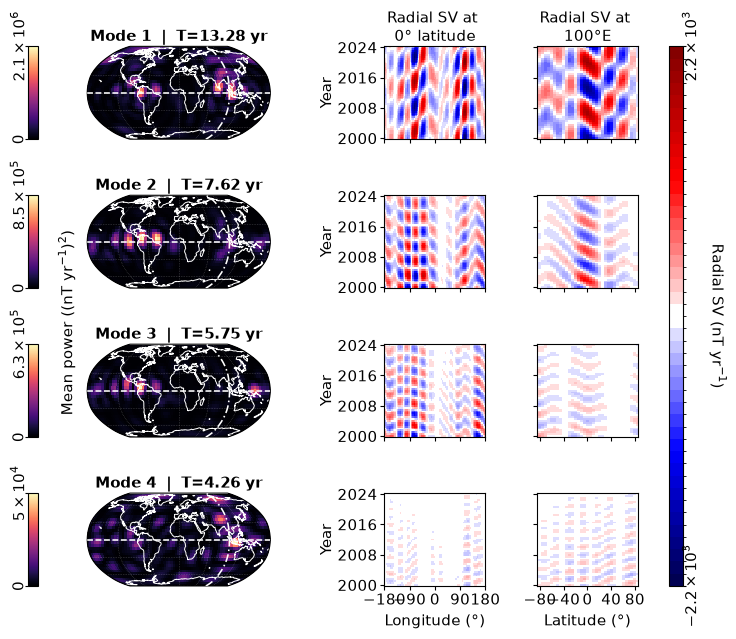

In [34]:
feasible_record_suite = {
    (
        f"{chaos_mode_suite[mode_key]['label']}\n"
        f"T={chaos_mode_suite[mode_key]['period']:.2f} yr"
    ): mode_records[mode_key]
    for mode_key in feasible_mode_keys
}
evolution_figure, evolution_axes = Plot_Equatorial_And_Power(
    feasible_record_suite,
    slice_latitude=slice_latitude,
    slice_longitude=slice_longitude,
    figure_width=1 * text_width,
    font_size=font_size,
    sv_step=100.0,
)
directional_interpretation_paths = Save_Interpretation_Figure(
    evolution_figure,
    'chaos_sv_equatorial_meridional_interpretation',
)
plt.show()

## (supplementary) Generating uncertainty-derived visualisation threshold

In [14]:
perturbation_path = (f"{CHAOS_COV_DIR}/CHAOS_0806_nmax15_BSpl_nT_perturbations_Hleft_N1000.h5")

A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=9)
n_realisations = 1000
max_signal_amp = []
with h5py.File(perturbation_path, "r") as f:

    for ensemble_idx in range(n_realisations):

        # loading in i-th perturbation gauss time series
        spline_perturbation_i = f["perturbations"][ensemble_idx]
        gnm_perturbation_i = H_sv @ spline_perturbation_i
        # truncation perturbation gauss time series to nmax
        gnm_perturbation_i = Truncate_Gauss_Coeffs(gnm_perturbation_i, tmax=9)

        # projecting to physical space
        physical_perturbation = A_r @ gnm_perturbation_i.T

        amp = np.max(np.abs(physical_perturbation))
        #amp = np.percentile(np.abs(physical_perturbation), 99)
        max_signal_amp.append(amp)

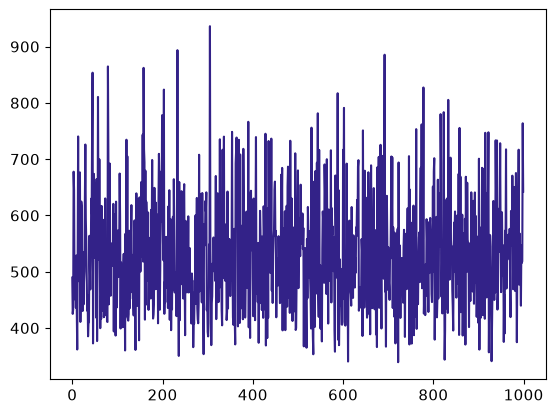

In [15]:
plt.plot(max_signal_amp)

In [16]:
print(np.percentile(max_signal_amp, 50))

518.9799484239013
